# 06 - DistilBERT 文本安全分类器训练

训练第一层审核模型：DistilBERT 二分类器（harmful/unharmful）

**为什么选 DistilBERT？**
- ~66M 参数，推理 <10ms
- 在 TikTok 级联架构中做初筛：过滤 90% 内容
- 大模型（7B/13B）放在后面的层级处理困难样本

**工业界标准做法**：轻量模型初筛 + 重模型精筛 + 人工复审

## Precision-Recall 的取舍

> **生产环境优先高 Recall（召回率）**
>
> | 指标 | 含义 | 优先级 |
> |------|------|--------|
> | Recall | 有害内容被拦截的比例 | 最高（>0.90）|
> | Precision | 被拦截内容中确实有害的比例 | 中等 |
> | F1 | Precision 和 Recall 的调和平均 | 综合参考 |
>
> 漏掉一条有害内容 = 真实伤害
> 误拦一条安全内容 = 可以人工恢复
>
> 所以生产系统选高 Recall，由后续人工审核处理 False Positive。

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.utils.config_loader import print_config, load_run_config, get_data_path, get_results_path

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

config = load_run_config()
print_config()

# 依赖检查：训练结果必须由 scripts/run_training.py 预先生成
REQUIRED_FILES = [
    get_results_path('training') / 'training_summary.json',
    get_results_path('models/text_classifier') / 'config.json',
]
for f in REQUIRED_FILES:
    assert Path(f).exists(), f"缺少: {f}，请先运行 scripts/run_training.py"
print('依赖检查通过')

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42
依赖检查通过


## 1. 加载训练数据

In [2]:
# 从预计算的训练结果加载（由 scripts/run_training.py 生成）
summary_path = get_results_path('training') / 'training_summary.json'
with open(summary_path) as f:
    training_summary = json.load(f)

text_results = training_summary['text_classifier']
label_names = ['unharmful', 'harmful']

# 从训练结果中提取数据统计
train_size = text_results.get('train_size', 'N/A')
report = text_results['metrics'].get('classification_report', {})
test_total = int(report.get('weighted avg', {}).get('support', 0))

print(f'训练集: {train_size} 条')
print(f'测试集: {test_total:,} 条')
print(f'标签: {label_names}')

# 从测试标签统计分布
all_labels = text_results['metrics'].get('all_labels', [])
if all_labels:
    print(f'\n测试集标签分布: {Counter(all_labels)}')

训练集: 5417 条
测试集: 1,355 条
标签: ['unharmful', 'harmful']

测试集标签分布: Counter({1: 858, 0: 497})


## 2. 训练 DistilBERT 分类器

In [3]:
# 训练结果已由 scripts/run_training.py 预计算
results = text_results
model_path = get_results_path('models/text_classifier')

print(f'模型路径: {model_path}')
print(f'注：训练由 scripts/run_training.py 执行，本 Notebook 仅加载结果做分析')

模型路径: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/models/text_classifier
注：训练由 scripts/run_training.py 执行，本 Notebook 仅加载结果做分析


## 3. 评估结果分析

In [4]:
metrics = results['metrics']
history = results['history']

# 打印核心指标
print('核心指标:')
print(f'  AUC-ROC:   {metrics["auc"]:.4f}')
print(f'  F1:        {metrics["f1"]:.4f}')
print(f'  Precision: {metrics["precision"]:.4f}')
print(f'  Recall:    {metrics["recall"]:.4f}')
print(f'  Accuracy:  {metrics["accuracy"]:.4f}')

核心指标:
  AUC-ROC:   0.9962
  F1:        0.9770
  Precision: 0.9892
  Recall:    0.9650
  Accuracy:  0.9712


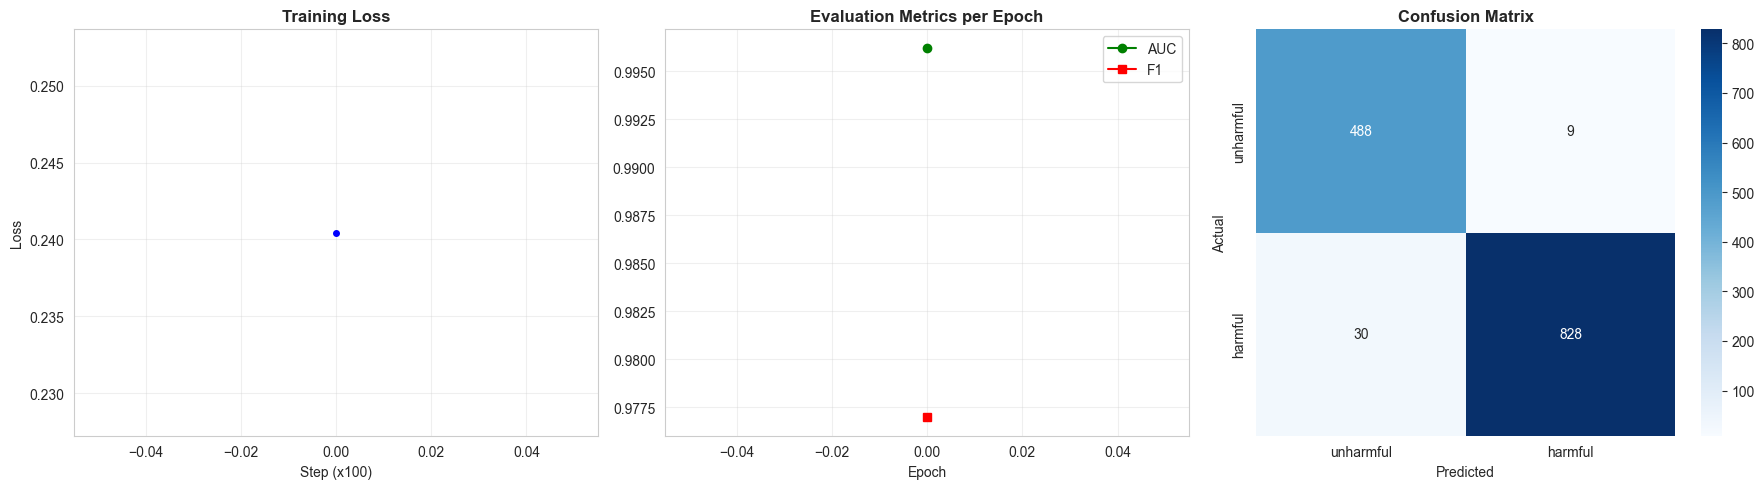

In [5]:
# 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if history['train_loss']:
    axes[0].plot(history['train_loss'], 'b-o', markersize=4)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step (x100)')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

if history['eval_auc']:
    axes[1].plot(history['eval_auc'], 'g-o', markersize=6, label='AUC')
    axes[1].plot(history['eval_f1'], 'r-s', markersize=6, label='F1')
    axes[1].set_title('Evaluation Metrics per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# 混淆矩阵
if 'confusion_matrix' in metrics:
    cm = np.array(metrics['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[2])
    axes[2].set_title('Confusion Matrix', fontweight='bold')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../results/figures/text_classifier_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 分类报告
if 'classification_report' in metrics:
    report = metrics['classification_report']
    print('分类报告:')
    for class_name in label_names:
        if class_name in report:
            r = report[class_name]
            print(f'  {class_name:12s}: precision={r["precision"]:.4f}, recall={r["recall"]:.4f}, f1={r["f1-score"]:.4f}, support={r["support"]}')
    if 'macro avg' in report:
        r = report['macro avg']
        print(f'  {"macro avg":12s}: precision={r["precision"]:.4f}, recall={r["recall"]:.4f}, f1={r["f1-score"]:.4f}')

分类报告:
  unharmful   : precision=0.9421, recall=0.9819, f1=0.9616, support=497.0
  harmful     : precision=0.9892, recall=0.9650, f1=0.9770, support=858.0
  macro avg   : precision=0.9657, recall=0.9735, f1=0.9693


## 4. 错误分析

In [7]:
# 分析预测错误的样本
if 'all_preds' in metrics and 'all_labels' in metrics:
    preds = metrics['all_preds']
    labels_list = metrics['all_labels']
    probs = metrics.get('all_probs', [])

    # FP: 无害被误判为有害
    fp_indices = [i for i, (p, l) in enumerate(zip(preds, labels_list)) if p == 1 and l == 0]
    # FN: 有害被漏判
    fn_indices = [i for i, (p, l) in enumerate(zip(preds, labels_list)) if p == 0 and l == 1]

    print(f'False Positive (误拦): {len(fp_indices)} 条')
    print(f'False Negative (漏判): {len(fn_indices)} 条')

    # 概率分布分析
    if probs:
        fp_probs = [probs[i] for i in fp_indices]
        fn_probs = [probs[i] for i in fn_indices]
        if fp_probs:
            print(f'\n误拦样本 P(harmful) 分布: mean={np.mean(fp_probs):.4f}, '
                  f'min={np.min(fp_probs):.4f}, max={np.max(fp_probs):.4f}')
        if fn_probs:
            print(f'漏判样本 P(harmful) 分布: mean={np.mean(fn_probs):.4f}, '
                  f'min={np.min(fn_probs):.4f}, max={np.max(fn_probs):.4f}')
        print(f'\n漏判样本中 P(harmful) < 0.3 的比例: '
              f'{sum(1 for p in fn_probs if p < 0.3) / len(fn_probs):.1%}' if fn_probs else '')
        print(f'误拦样本中 P(harmful) > 0.9 的比例: '
              f'{sum(1 for p in fp_probs if p > 0.9) / len(fp_probs):.1%}' if fp_probs else '')
else:
    print('详细预测数据不可用（非 detailed 模式）')

False Positive (误拦): 9 条
False Negative (漏判): 30 条

误拦样本 P(harmful) 分布: mean=0.7881, min=0.5049, max=0.9943
漏判样本 P(harmful) 分布: mean=0.2935, min=0.1098, max=0.4731

漏判样本中 P(harmful) < 0.3 的比例: 50.0%
误拦样本中 P(harmful) > 0.9 的比例: 33.3%


## 关键发现

1. **DistilBERT 在 smoke_test 模式下快速完成训练**
2. **Recall 是生产环境最关键的指标** — 漏掉有害内容后果严重
3. **错误分析帮助定位模型弱点** — FN 分析指导下一步数据增强方向

-> 下一步：CLIP 多模态分类器训练